# Feature Engineering

**Goal:** Transform raw OHLCV data into a rich feature matrix that the ML model can learn from.

### Why do we need features?
Raw price data alone is weak. The model needs **context**:
- Is the price trending up or down? → EMA
- Is the market overbought? → RSI
- Is momentum increasing? → MACD
- How volatile is the market right now? → Bollinger Bands
- What did the price do 5 candles ago? → Lag features

### What we build:
| Group | Indicators |
|-------|------------|
| Trend | EMA 9, 21, 50 |
| Momentum | RSI 14, MACD, MACD Signal, Histogram |
| Volatility | Bollinger Bands (upper, lower, width, %B) |
| Volume | OBV, Volume EMA, Volume ratio |
| Lag features | Close lag 1–5, Volume lag 1–3 |
| Rolling stats | Rolling mean, std, min, max (10 & 30 periods) |
| Returns | 1, 3, 5, 12 candle returns |
| Candle shape | Body size, upper/lower wick |

### — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

import ta
from ta.trend      import EMAIndicator, MACD
from ta.momentum   import RSIIndicator
from ta.volatility import BollingerBands
from ta.volume     import OnBalanceVolumeIndicator

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

CLEAN_PATH   = '../data/processed/btc_5m_clean.csv'
FEATURE_PATH = '../data/processed/btc_5m_features.csv'

### — Load Cleaned Data

In [2]:
df = pd.read_csv(CLEAN_PATH, index_col=0, parse_dates=True)
if df.index.tz is None:
    df.index = df.index.tz_localize('UTC')
    
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df.index.min()} -> {df.index.max()}')
df.head(3)

Loaded: 49,950 rows x 11 columns
Date range: 2025-09-16 03:00:00+00:00 -> 2026-03-08 13:25:00+00:00


,open,high,low,close,volume,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote,next_close,direction
open_time,,,,,,,,,,,
2025-09-16 03:00:00+00:00,115034.48,115149.43,115034.44,115143.83,16.55927,1906008.682,5527,10.84775,1.248542e+06,115082.15,0
2025-09-16 03:05:00+00:00,115143.84,115179.77,115082.14,115082.15,11.61962,1337826.988,4682,3.87515,4.461520e+05,115114.00,1
2025-09-16 03:10:00+00:00,115082.15,115119.36,115082.14,115114.00,9.62778,1108186.407,2832,5.04930,5.811822e+05,115124.42,1


---
### — EMA (Exponential Moving Average)
---

#### What is EMA?
EMA is the average price over N candles but gives **more weight to recent candles**.
Unlike SMA where all candles count equally, EMA reacts faster to new price moves.

```
EMA 9  → short-term trend  (last ~45 min)
EMA 21 → medium-term trend (last ~1.75 hours)
EMA 50 → long-term trend   (last ~4 hours)
```

**Golden signal:** EMA9 crosses above EMA21 → bullish. Below → bearish.

We also compute how far the current price is FROM each EMA — this tells the model
if price is stretched too far above/below its average (potential reversal signal).

EMA features created


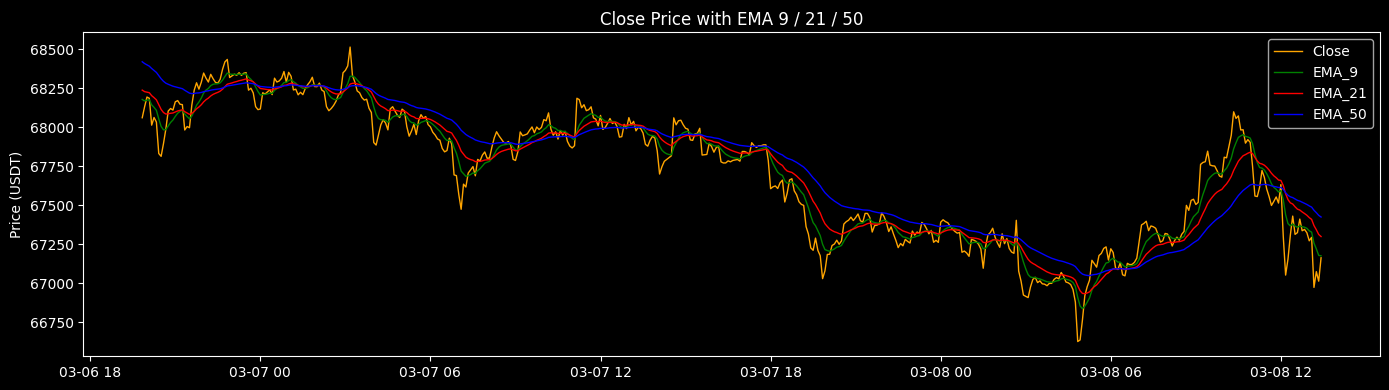

In [3]:
df['ema_9'] = EMAIndicator(close=df['close'], window=9).ema_indicator()
df['ema_21'] = EMAIndicator(close=df['close'], window=21).ema_indicator()
df['ema_50'] = EMAIndicator(close=df['close'], window=50).ema_indicator()

# Distance from EMA as percentage
# Positive = price above EMA (bullish), Negative = below (bearish)
df['price_vs_ema9']  = ((df['close'] - df['ema_9'])  / df['ema_9'])  * 100
df['price_vs_ema21'] = ((df['close'] - df['ema_21']) / df['ema_21']) * 100
df['price_vs_ema50'] = ((df['close'] - df['ema_50']) / df['ema_50']) * 100

# Crossover signals (binary)
df['ema9_above_ema21'] = (df['ema_9'] > df['ema_21']).astype(int)
df['ema21_above_ema50'] = (df['ema_21'] > df['ema_50']).astype(int)

print('EMA features created')

# Visualize
fig, ax = plt.subplots(figsize=(14,4))
sample = df.iloc[-500:]
ax.plot(sample.index, sample['close'], color = 'orange', lw = 1, label = 'Close')
ax.plot(sample.index, sample['ema_9'], color = 'green', lw = 1, label = 'EMA_9')
ax.plot(sample.index, sample['ema_21'], color = 'red', lw = 1, label = 'EMA_21')
ax.plot(sample.index, sample['ema_50'], color = 'blue', lw = 1, label = 'EMA_50')
ax.set_ylabel('Price (USDT)')
ax.set_title('Close Price with EMA 9 / 21 / 50')
ax.legend()
plt.tight_layout()
plt.show()

---
### — RSI (Relative Strength Index)
---
#### What is RSI?
RSI measures **how fast and how much** price has been moving. Always 0–100.

```
RSI > 70  →  Overbought  (may reverse DOWN)
RSI < 30  →  Oversold    (may reverse UP)
RSI = 50  →  Neutral
```

Formula over last 14 candles:
```
RS  = avg_gain / avg_loss
RSI = 100 - (100 / (1 + RS))
```

We compute RSI at 3 speeds: fast (7), standard (14), slow (21).

RSI features created


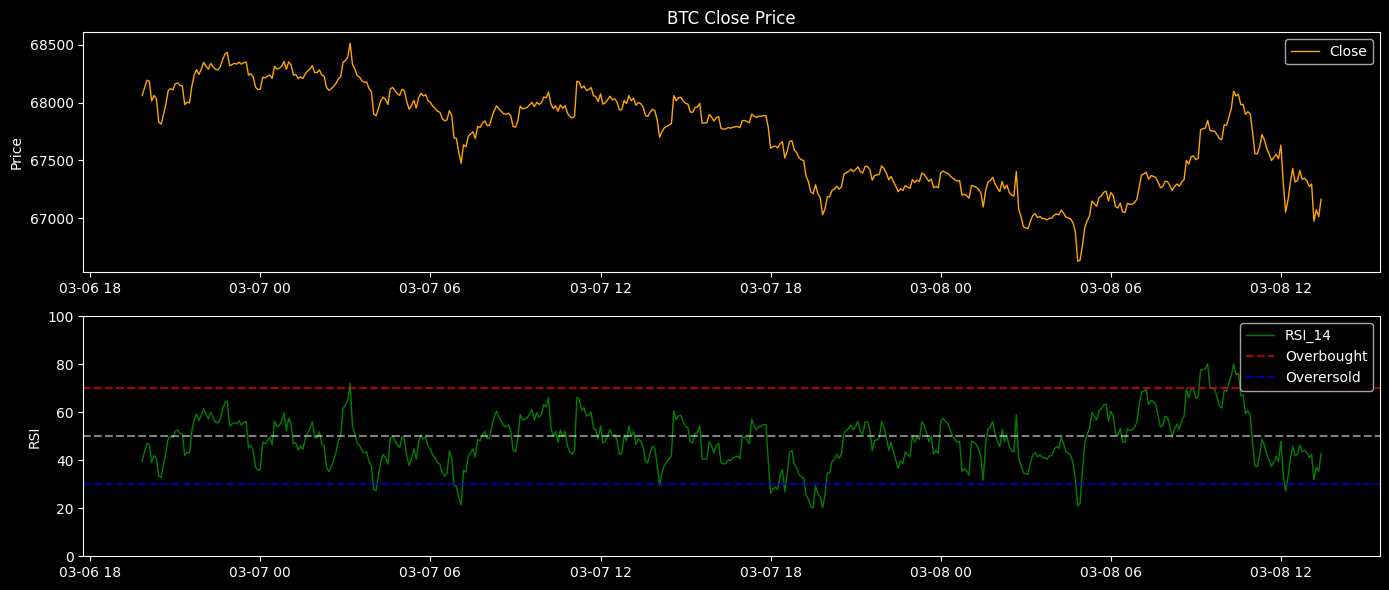

In [4]:
df['rsi_7']  = RSIIndicator(close = df['close'], window = 7).rsi() # faster, noisier
df['rsi_14'] = RSIIndicator(close = df['close'], window = 14).rsi()
df['rsi_21'] = RSIIndicator(close = df['close'], window = 21).rsi() # slower, smoother

# Overbought / Oversold binary flags
df['rsi_overbought'] = (df['rsi_14'] > 70).astype(int)
df['rsi_oversold']   = (df['rsi_14'] < 30).astype(int)

# RSI slope — is momentum building or fading?
df['rsi_slope'] = df['rsi_14'].diff(3)

print('RSI features created')

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14,6))
sample = df.iloc[-500:]
ax1.plot(sample.index, sample['close'], color='orange', lw=1, label='Close')
ax1.set_title('BTC Close Price')
ax1.set_ylabel('Price')
ax1.legend()

ax2.plot(sample.index, sample['rsi_14'], color='green', lw=1, label='RSI_14')
ax2.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought')
ax2.axhline(50, color='white', linestyle='--', alpha=0.5)
ax2.axhline(30, color='blue', linestyle='--', alpha=0.7, label='Overersold')
ax2.set_ylim(0,100)
ax2.set_ylabel('RSI')
ax2.legend()
plt.tight_layout()
plt.show()

---
### Cell 5 — MACD
---

### What is MACD?
MACD : Moving Average Convergence Divergence

Tracks the relationship between two EMAs to identify momentum shifts.

```
MACD Line   = EMA(12) - EMA(26)
Signal Line = EMA(9) of MACD Line
Histogram   = MACD Line - Signal Line
```

**Histogram > 0 and growing** → bullish momentum increasing
**MACD crosses above Signal** → buy signal

We normalize MACD by price so it's comparable across different price levels.

MACD features created


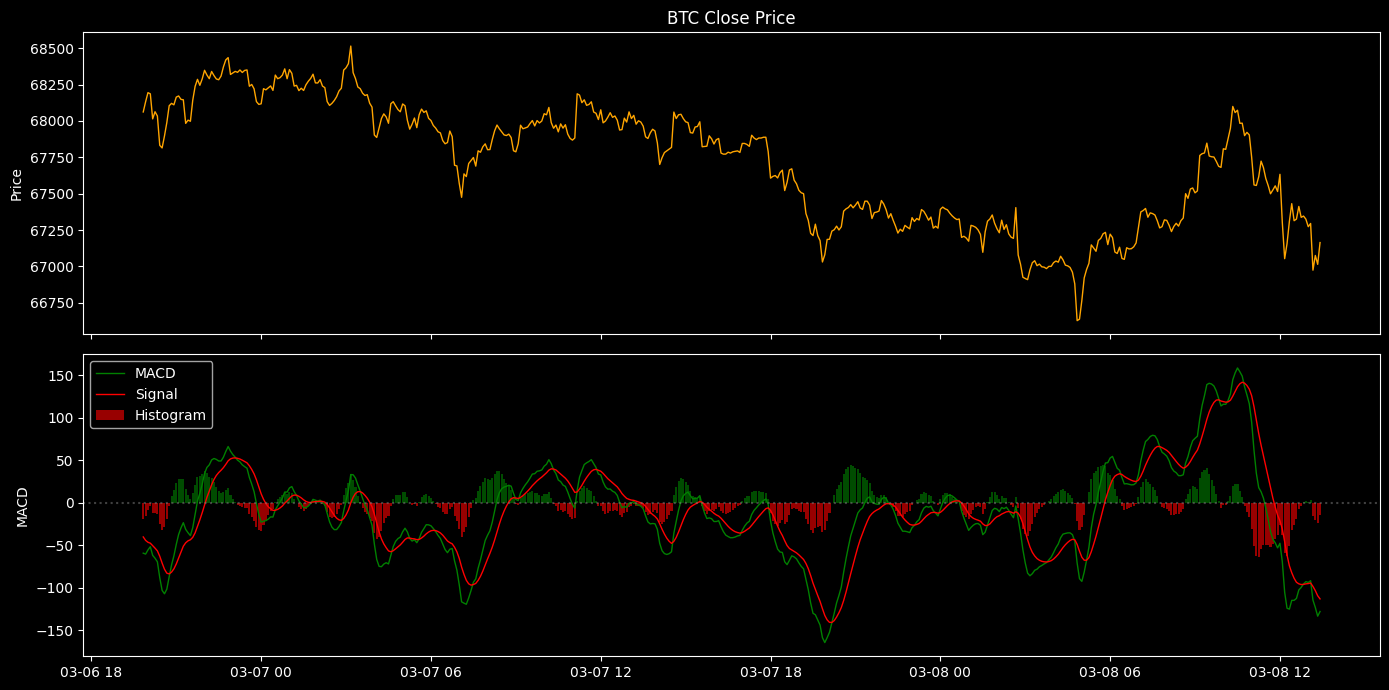

In [5]:
macd_ind = MACD(close=df['close'], window_slow=26, window_fast=12, window_sign=9)
df['macd']             = macd_ind.macd()
df['macd_signal']      = macd_ind.macd_signal()
df['macd_hist']        = macd_ind.macd_diff()
df['macd_norm']        = df['macd'] / df['close'] * 100   # normalize by price
df['macd_above_signal']= (df['macd'] > df['macd_signal']).astype(int)
df['macd_hist_slope']  = df['macd_hist'].diff(2)

print('MACD features created')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
sample = df.iloc[-500:]
ax1.plot(sample.index, sample['close'], color='orange', lw=1)
ax1.set_title('BTC Close Price')
ax1.set_ylabel('Price')
ax2.plot(sample.index, sample['macd'],        color='green', lw=1, label='MACD')
ax2.plot(sample.index, sample['macd_signal'], color='red', lw=1, label='Signal')
colors = ['green' if v >= 0 else 'red' for v in sample['macd_hist']]
ax2.bar(sample.index, sample['macd_hist'], color=colors, alpha=0.6, width=0.003, label='Histogram')
ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax2.set_ylabel('MACD')
ax2.legend()
plt.tight_layout()
plt.show()

---
### — Bollinger Bands
---
```
Middle = SMA(20)
Upper  = SMA(20) + 2 × StdDev
Lower  = SMA(20) - 2 × StdDev
```

95% of price stays inside. When price breaks outside → extreme move.

**Band Width** = volatility. Narrow = squeeze = big move coming.
**%B** = where inside bands is price right now (0=lower, 1=upper, 0.5=middle).

Bollinger Band features created


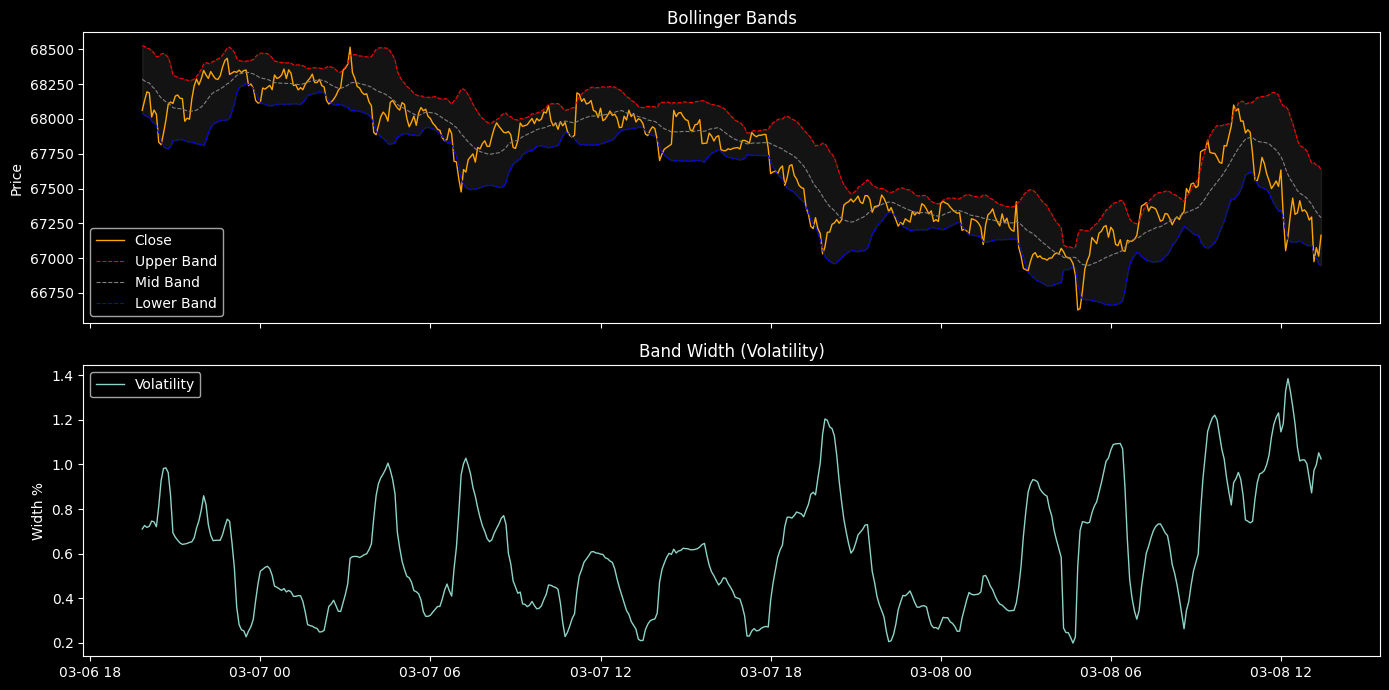

In [6]:
bb = BollingerBands(close=df['close'], window=20, window_dev=2)
df['bb_upper'] = bb.bollinger_hband()
df['bb_mid']   = bb.bollinger_mavg()
df['bb_lower'] = bb.bollinger_lband()
df['bb_width'] = bb.bollinger_wband()
df['bb_pct']   = bb.bollinger_pband()
df['bb_above_upper'] = (df['close'] > df['bb_upper']).astype(int)
df['bb_below_lower'] = (df['close'] < df['bb_lower']).astype(int)

print('Bollinger Band features created')

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14,7),sharex=True)
sample = df.iloc[-500:]
ax1.plot(sample.index, sample['close'],    color='orange', lw=1, label='Close')
ax1.plot(sample.index, sample['bb_upper'], color='red',    lw=0.8, linestyle='--', label='Upper Band')
ax1.plot(sample.index, sample['bb_mid'],   color='gray',   lw=0.8, linestyle='--', label='Mid Band')
ax1.plot(sample.index, sample['bb_lower'], color='blue',   lw=0.8, linestyle='--', label='Lower Band')
ax1.fill_between(sample.index, sample['bb_upper'], sample['bb_lower'], alpha=0.08, color='white')
ax1.set_title('Bollinger Bands')
ax1.set_ylabel('Price')
ax1.legend()

ax2.plot(sample.index, sample['bb_width'], lw=1, label='Volatility')
ax2.set_title('Band Width (Volatility)')
ax2.set_ylabel('Width %')
ax2.legend()
plt.tight_layout()
plt.show()

---
### — Volume Features
---
**OBV (On-Balance Volume)** = running total that adds volume on UP candles, subtracts on DOWN.

Rising OBV = buying pressure. Falling = selling pressure.

**Volume ratio** = current volume / 20-period average.
>1 means above-average volume = stronger signal conviction.

In [7]:
df['obv'] = OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()
df['volume_ema_20'] = EMAIndicator(close=df['volume'], window=20).ema_indicator()
df['volume_ratio']  = df['volume'] / df['volume_ema_20']
df['high_volume']   = (df['volume_ratio'] > 2.0).astype(int)

print('Volume features created')
print(df[['volume','volume_ema_20','volume_ratio','high_volume']].tail(3).to_string())

Volume features created
                              volume  volume_ema_20  volume_ratio  high_volume
open_time                                                                     
2026-03-08 13:15:00+00:00  459.50701      98.252583      4.676793            1
2026-03-08 13:20:00+00:00   55.02959      94.136107      0.584575            0
2026-03-08 13:25:00+00:00  512.83130     134.011840      3.826761            1


---
### — Lag Features

Lag features give the model a **memory** of past candles.

```
lag_1 = price 1 candle ago (5 min)
lag_3 = price 3 candles ago (15 min)
```

We use **returns** (% changes) as lags — they're scale-free.

Always use `shift(+N)` for features. Never `shift(-N)` — that looks into the future!

In [8]:
# Close price lags
for lag in range(1,6):
    df[f'close_lag_{lag}'] = df['close'].shift(lag)

#return lags
df['return_1']  = df['close'].pct_change(1) * 100
df['return_3']  = df['close'].pct_change(3) * 100
df['return_5']  = df['close'].pct_change(5) * 100
df['return_12'] = df['close'].pct_change(12) * 100

#Volume Lags
for lag in range(1,4):
    df[f'volume_lag_{lag}'] = df['volume'].shift(lag)

print('Lag features created')
print(df[['return_1','return_3','return_5','return_12']].tail(3).round(4).to_string())

Lag features created
                           return_1  return_3  return_5  return_12
open_time                                                         
2026-03-08 13:15:00+00:00    0.1509   -0.2940   -0.4023    -0.1202
2026-03-08 13:20:00+00:00   -0.0909   -0.4176   -0.4613    -0.4386
2026-03-08 13:25:00+00:00    0.2234    0.2834   -0.1622    -0.3968


---
### Cell 9 — Rolling Statistics
---
A rolling window slides across time computing stats for each window.

- **Rolling mean** → where is price centered recently?
- **Rolling std**  → how volatile is price recently?
- **Z-score**      → how extreme is current price vs recent history?

`zscore > 2` = unusually high. `zscore < -2` = unusually low (potential reversal).

In [9]:
df['rolling_mean_10'] = df['close'].rolling(10).mean()
df['rolling_std_10']  = df['close'].rolling(10).std()
df['rolling_min_10']  = df['close'].rolling(10).min()
df['rolling_max_10']  = df['close'].rolling(10).max()

df['rolling_mean_30'] = df['close'].rolling(30).mean()
df['rolling_std_30']  = df['close'].rolling(30).std()
df['rolling_min_30']  = df['close'].rolling(30).min()
df['rolling_max_30']  = df['close'].rolling(30).max()

# Z-score: (price - mean) / std
df['zscore_10'] = (df['close'] - df['rolling_mean_10']) / df['rolling_std_10']
df['zscore_30'] = (df['close'] - df['rolling_mean_30']) / df['rolling_std_30']

# Price position within rolling range (0=at low, 1=at high)
range_10 = (df['rolling_max_10'] - df['rolling_min_10']).replace(0, np.nan)
df['price_position_10'] = (df['close'] - df['rolling_min_10']) / range_10

print('Rolling statistics created')
print(df[['rolling_mean_10','rolling_std_10','zscore_10','zscore_30']].tail(3).round(4).to_string())

Rolling statistics created
                           rolling_mean_10  rolling_std_10  zscore_10  zscore_30
open_time                                                                       
2026-03-08 13:15:00+00:00        67267.781        135.2827    -1.4237    -1.6139
2026-03-08 13:20:00+00:00        67237.773        155.5853    -1.4371    -1.7791
2026-03-08 13:25:00+00:00        67221.600        153.8362    -0.3752    -1.0849


---
### — Candle Shape Features

```
        │  ← upper wick (high - max(open,close))
       ███ ← body (abs(open - close))
        │  ← lower wick (min(open,close) - low)

Long upper wick → price rejected at highs (bearish)
Long lower wick → price bounced from lows (bullish)
Large body      → strong directional conviction
```

In [10]:
candle_range = (df['high'] - df['low']).replace(0,np.nan)

df['candle_body'] = (df['close'] - df['open']).abs()
df['body_ratio']  = (df['candle_body']) / candle_range
df['upper_wick']  = (df['high']  - df[['open','close']].max(axis=1))
df['lower_wick']  = (df[['open','close']].min(axis=1) - df['low'])
df['upper_wick_ratio'] = df['upper_wick'] / candle_range
df['lower_wick_ratio'] = df['lower_wick'] / candle_range

df['is_bullish_candle']= (df['close'] > df['open']).astype(int)

print('Candle shape features created')
print(df[['candle_body','body_ratio','upper_wick', 'upper_wick_ratio', 'lower_wick','lower_wick_ratio','is_bullish_candle']].tail(3).round(4).to_string())

Candle shape features created
                           candle_body  body_ratio  upper_wick  upper_wick_ratio  lower_wick  lower_wick_ratio  is_bullish_candle
open_time                                                                                                                        
2026-03-08 13:15:00+00:00       101.09      0.5054       24.82            0.1241       74.12            0.3705                  1
2026-03-08 13:20:00+00:00        60.99      0.4330       55.69            0.3954       24.18            0.1717                  0
2026-03-08 13:25:00+00:00       149.71      0.3882       35.66            0.0925      200.25            0.5193                  1


---
### — Drop NaN rows & Final Check
---

Technical indicators need a warm-up period. EMA 50 needs 49 rows before it outputs a value.

In [11]:
rows_before = len(df)
df.dropna(inplace=True)
rows_after  = len(df)

target_cols = ['next_close','direction']
feature_cols = [i for i in df.columns if i not in target_cols]

print(f'Rows before: {rows_before:,}')
print(f'Rows after : {rows_after:,}  ({rows_before-rows_after} dropped for warm-up)')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Total features: {len(feature_cols)}')
print(f'Length of Feature cols: {len(feature_cols)}, Length of Target cols: {len(df.columns)}')

Rows before: 49,950
Rows after : 49,901  (49 dropped for warm-up)
Missing values: 0
Total features: 70
Length of Feature cols: 70, Length of Target cols: 72


In [12]:
for i, col in enumerate(feature_cols, 1):
    print(f'{i:>2}. {col}')

 1. open
 2. high
 3. low
 4. close
 5. volume
 6. quote_asset_volume
 7. num_trades
 8. taker_buy_base
 9. taker_buy_quote
10. ema_9
11. ema_21
12. ema_50
13. price_vs_ema9
14. price_vs_ema21
15. price_vs_ema50
16. ema9_above_ema21
17. ema21_above_ema50
18. rsi_7
19. rsi_14
20. rsi_21
21. rsi_overbought
22. rsi_oversold
23. rsi_slope
24. macd
25. macd_signal
26. macd_hist
27. macd_norm
28. macd_above_signal
29. macd_hist_slope
30. bb_upper
31. bb_mid
32. bb_lower
33. bb_width
34. bb_pct
35. bb_above_upper
36. bb_below_lower
37. obv
38. volume_ema_20
39. volume_ratio
40. high_volume
41. close_lag_1
42. close_lag_2
43. close_lag_3
44. close_lag_4
45. close_lag_5
46. return_1
47. return_3
48. return_5
49. return_12
50. volume_lag_1
51. volume_lag_2
52. volume_lag_3
53. rolling_mean_10
54. rolling_std_10
55. rolling_min_10
56. rolling_max_10
57. rolling_mean_30
58. rolling_std_30
59. rolling_min_30
60. rolling_max_30
61. zscore_10
62. zscore_30
63. price_position_10
64. candle_body
65. bo

---
### — Feature Correlation Heatmap

Highly correlated features (>0.95) are redundant — they tell the model the same thing.
XGBoost handles this naturally but it's good practice to visualize it.

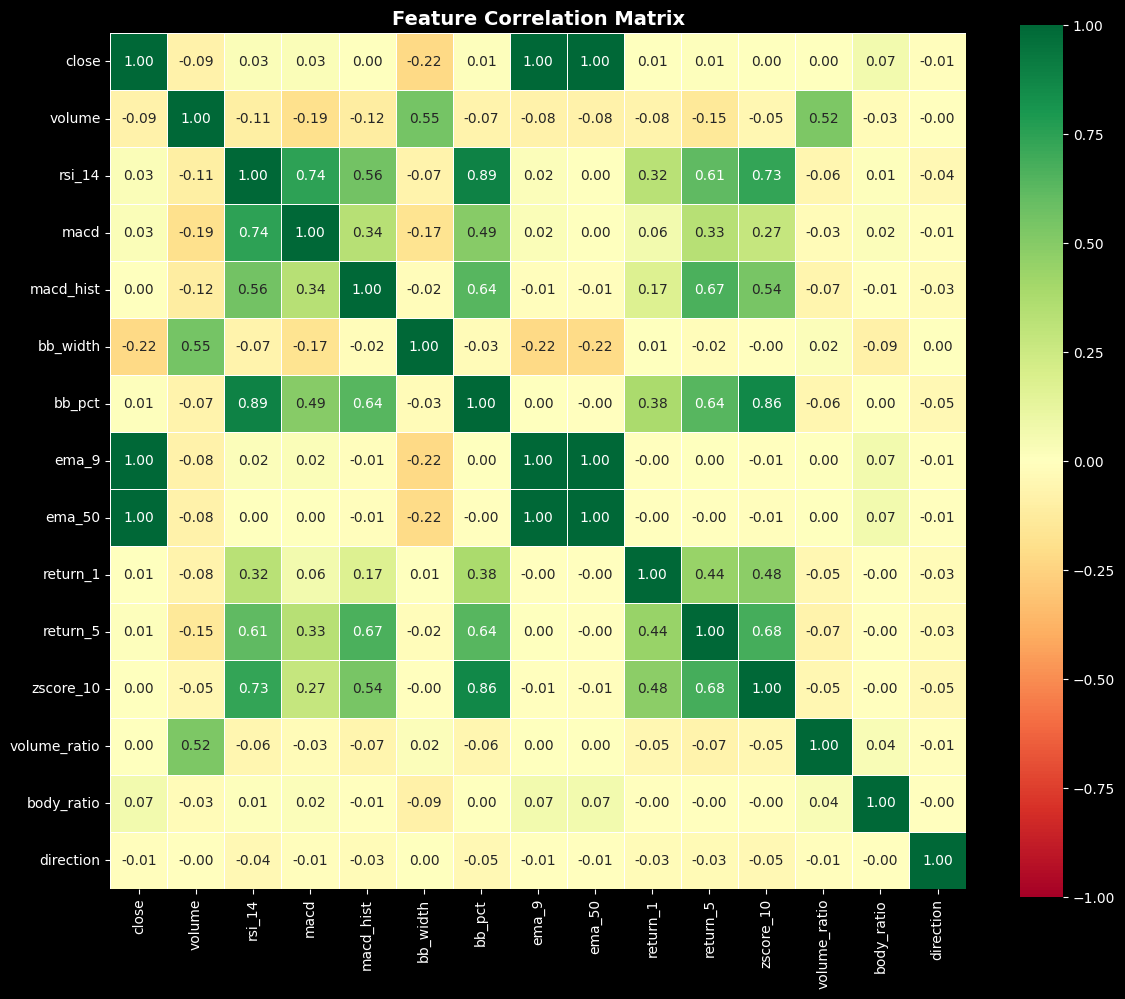

In [47]:
key_features = ['close','volume','rsi_14','macd','macd_hist',
                'bb_width','bb_pct','ema_9','ema_50',
                'return_1','return_5','zscore_10','volume_ratio',
                'body_ratio','direction']

corr = df[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.savefig('../data/processed/feature_correlation.png', dpi=120, bbox_inches='tight')
plt.tight_layout()
plt.show()

###  — Feature vs Target Distribution
Do our features actually differ between UP and DOWN candles?
If RSI is identical for both → RSI is useless. We want to see clear separation.

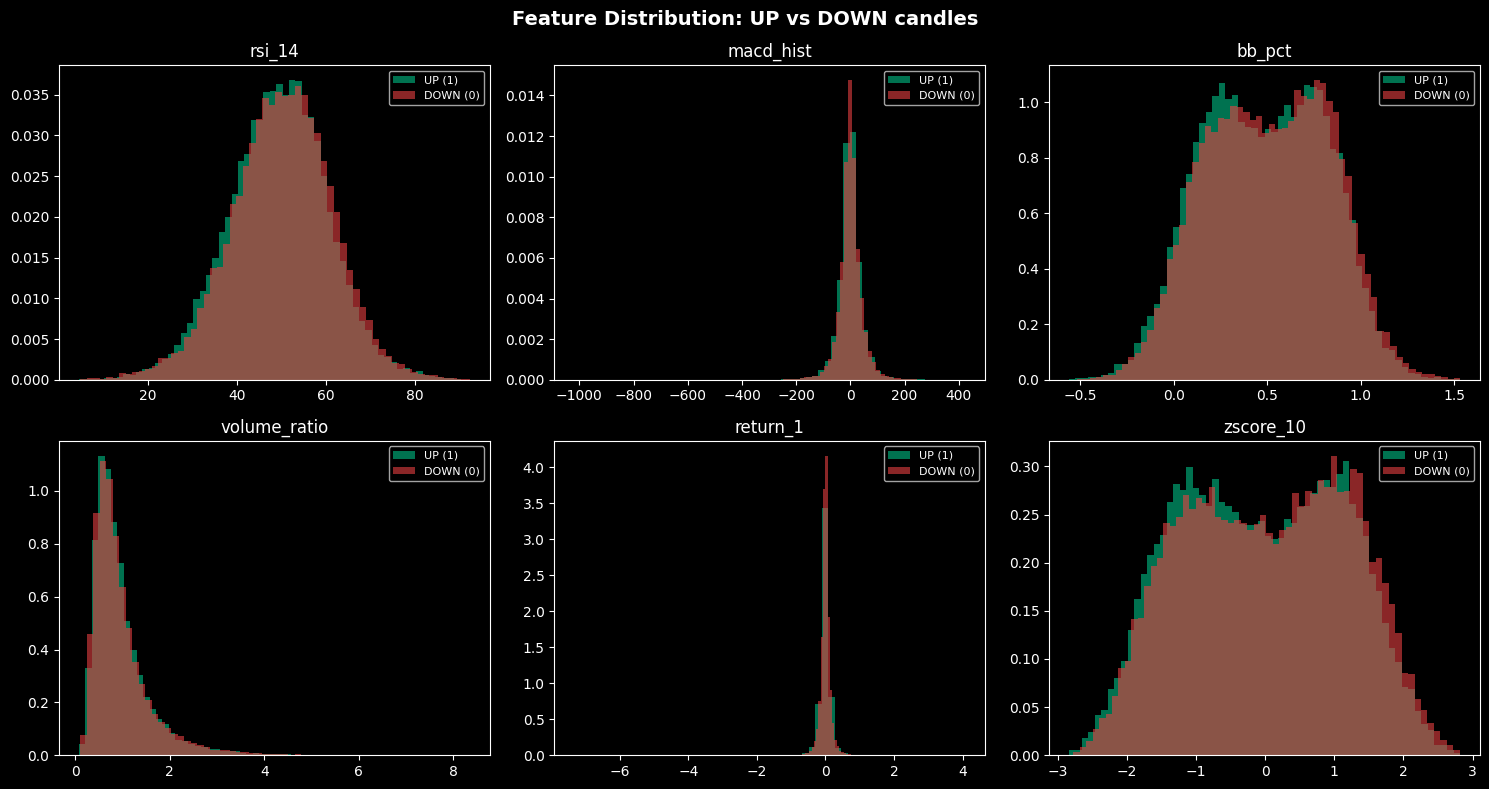

Separation between green/red bars = feature is useful!


In [52]:
features_to_check = ['rsi_14','macd_hist','bb_pct','volume_ratio','return_1','zscore_10']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distribution: UP vs DOWN candles', fontsize=14, fontweight='bold')
axes = axes.flatten()

up_df   = df[df['direction'] == 1]
down_df = df[df['direction'] == 0]

for i, feat in enumerate(features_to_check):
    axes[i].hist(up_df[feat].dropna(),   bins=60, alpha=0.6, color='#00C087', label='UP (1)',   density=True)
    axes[i].hist(down_df[feat].dropna(), bins=60, alpha=0.6, color='#E84142', label='DOWN (0)', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Separation between green/red bars = feature is useful!')

### — Save Feature Matrix

In [53]:
os.makedirs(os.path.dirname(FEATURE_PATH), exist_ok=True)
df.to_csv(FEATURE_PATH)

size_kb = os.path.getsize(FEATURE_PATH) / 1024
print('Feature matrix saved!')
print(f'   Path  : {FEATURE_PATH}')
print(f'   Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'   Size  : {size_kb:.0f} KB')
print()
df.tail(3)

Feature matrix saved!
   Path  : ../data/processed/btc_5m_features.csv
   Shape : 49,901 rows x 72 columns
   Size  : 47975 KB



,open,high,low,close,volume,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote,next_close,...,zscore_10,zscore_30,price_position_10,candle_body,body_ratio,upper_wick,lower_wick,upper_wick_ratio,lower_wick_ratio,is_bullish_candle
open_time,,,,,,,,,,,,,,,,,,,,,
2026-03-08 13:15:00+00:00,66974.09,67100.00,66899.97,67075.18,459.50701,3.078469e+07,16318,358.83986,2.404119e+07,67014.18,...,-1.423693,-1.613903,0.230718,101.09,0.505374,24.82,74.12,0.124081,0.370544,1
2026-03-08 13:20:00+00:00,67075.17,67130.86,66990.00,67014.18,55.02959,3.690291e+06,9441,14.58374,9.784266e+05,67163.88,...,-1.437109,-1.779098,0.091484,60.99,0.432983,55.69,24.18,0.395357,0.171660,0
2026-03-08 13:25:00+00:00,67014.17,67199.54,66813.92,67163.88,512.83130,3.434200e+07,33374,430.76162,2.884565e+07,67088.01,...,-0.375204,-1.084902,0.433179,149.71,0.388232,35.66,200.25,0.092474,0.519294,1
